# Import library

In [75]:
import pandas as pd

In [76]:
df = pd.read_excel("https://raw.githubusercontent.com/dzulfi02/data_analis/main/Online%20Retail.xlsx")

In [77]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## Melihat informasi dataset

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## Melihat statistik dasar

In [79]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [80]:
df['UnitPrice'].max()

38970.0

In [81]:
df['UnitPrice'].min()

-11062.06

#Data Cleaning

## Duplikat

In [82]:
df.duplicated().sum()

np.int64(5268)

In [83]:
df.drop_duplicates(inplace=True)

In [84]:
df.duplicated().sum()

np.int64(0)

##Missing value data

In [85]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


In [86]:
df['Description'] = df['Description'].fillna(
    df.groupby('StockCode')['Description'].transform('first')
)

In [87]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,112
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


##Outliners

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

#melihat ada berapa outliner di dalam dataset
for col in df.select_dtypes(include='number').columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    if outlier_count > 0:
        print(f"{col} memiliki {outlier_count} outlier")

Quantity memiliki 58501 outlier
UnitPrice memiliki 39450 outlier


<Axes: ylabel='UnitPrice'>

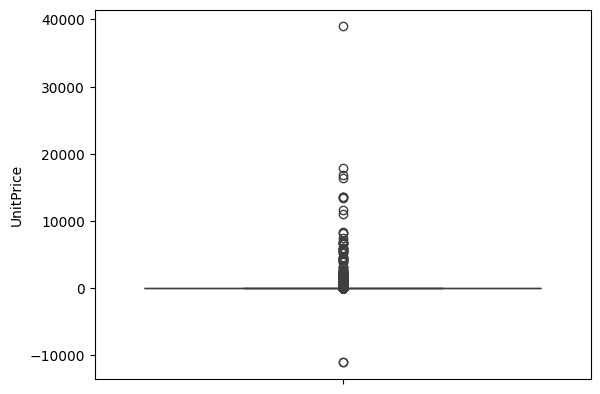

In [89]:
sns.boxplot(df['UnitPrice'])

##Ubah tipe data

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  536529 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[ns]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      536641 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.8+ MB


In [91]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [92]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.date

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  536529 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


#Tambah Kolom

In [94]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680.0,France,16.60


In [95]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34


#Insight

## 1. Keterkaitan antar jumlah transaksi per negara

In [96]:
df['Country'].value_counts()

,count
Country,
United Kingdom,490300
Germany,9480
France,8541
EIRE,8184
Spain,2528
Netherlands,2371
Belgium,2069
Switzerland,1994
Portugal,1510


## 2. Banyaknya produk yang terjual

In [97]:
df.groupby(['StockCode','Description'])['Quantity'].sum().sort_values(ascending=False)

,,Quantity
StockCode,Description,
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751
85099B,JUMBO BAG RED RETROSPOT,47260
22197,POPCORN HOLDER,36322
84879,ASSORTED COLOUR BIRD ORNAMENT,36282
21212,PACK OF 72 RETROSPOT CAKE CASES,36016
...,...,...
20713,wrongly marked. 23343 in box,-3100
79323W,"Unsaleable, destroyed.",-4830
72140F,throw away,-5368


## 3. Jumlah nominal pembelian per-negara

In [98]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
Country,
United Kingdom,8167128.184
Netherlands,284661.540
EIRE,262993.380
Germany,221509.470
France,197317.110
Australia,137009.770
Switzerland,56363.050
Spain,54756.030
Belgium,40910.960


##4. Customer yang sering melakukan transaksi pembelian

In [99]:
df.groupby(['CustomerID','Country'])['TotalPrice'].sum().sort_values(ascending=False)

,,TotalPrice
CustomerID,Country,
14646.0,Netherlands,279489.02
18102.0,United Kingdom,256438.49
17450.0,United Kingdom,187322.17
14911.0,EIRE,132458.73
12415.0,Australia,123725.45
...,...,...
12503.0,Spain,-1126.00
17603.0,United Kingdom,-1165.30
14213.0,United Kingdom,-1192.20


##5. Melihat penjualan perhari

In [100]:
df.groupby('InvoiceDate')['Quantity'].sum().sort_values(ascending=False)

,Quantity
InvoiceDate,
2011-10-05,46097
2011-11-14,45842
2011-12-05,44038
2011-09-20,43659
2011-10-20,40738
...,...
2011-07-03,3080
2011-03-13,2725
2011-02-13,2682


## 6. Menghitung total transaksi yang berhasil dan dibatalkan

In [101]:
df['Transaction_Status'] = ~df['InvoiceNo'].astype(str).str.startswith('C')

In [102]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Transaction_Status
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30,True
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,True
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00,True
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,True
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,True
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,12680.0,France,10.20,True
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680.0,France,12.60,True
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680.0,France,16.60,True
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680.0,France,16.60,True


In [103]:
df['Transaction_Status'].value_counts()

,count
Transaction_Status,
True,527390
False,9251


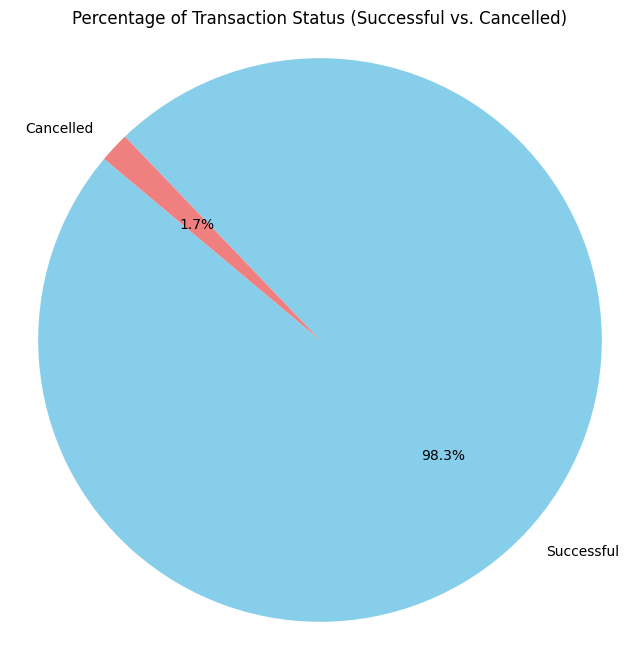

In [104]:
import matplotlib.pyplot as plt

status_counts = df['Transaction_Status'].value_counts(normalize=True) * 100
labels = ['Successful' if idx else 'Cancelled' for idx in status_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
plt.title('Percentage of Transaction Status (Successful vs. Cancelled)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##7. Produk yang sering dibatalkan transaksinya

In [105]:
df.groupby('Description')['Transaction_Status'].sum().sort_values(ascending=False)

,Transaction_Status
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2315
JUMBO BAG RED RETROSPOT,2112
REGENCY CAKESTAND 3 TIER,2009
PARTY BUNTING,1700
LUNCH BAG RED RETROSPOT,1581
...,...
CRUK Commission,0
SWEETHEART KEY CABINET,0
TEA TIME CAKE STAND IN GIFT BOX,0


In [106]:
df[df['Transaction_Status'] == False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Transaction_Status
141,C536379,D,Discount,-1,2010-12-01,27.50,14527.0,United Kingdom,-27.50,False
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01,4.65,15311.0,United Kingdom,-4.65,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01,1.65,17548.0,United Kingdom,-19.80,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01,0.29,17548.0,United Kingdom,-6.96,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01,0.29,17548.0,United Kingdom,-6.96,False
...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09,0.83,14397.0,United Kingdom,-9.13,False
541541,C581499,M,Manual,-1,2011-12-09,224.69,15498.0,United Kingdom,-224.69,False
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09,10.95,15311.0,United Kingdom,-54.75,False
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09,1.25,17315.0,United Kingdom,-1.25,False


## 8. Jumlah nominal dari pembatalan transaksi

In [115]:
sukses = df[df['TotalPrice'] > 0]
gagal = df[df['TotalPrice'] < 0]

# 3. Perhitungan Metrik Finansial Utama
nilai_sukses = sukses['TotalPrice'].sum()
nilai_gagal = gagal['TotalPrice'].sum()  # Nilainya akan negatif
absolute_gagal = abs(nilai_gagal) #mempositifkan nilai_gagal
net = nilai_sukses - absolute_gagal
persentase = (absolute_gagal / nilai_sukses) * 100
persentase

np.float64(8.608290844478601)

#Eksport data

In [120]:
!pip install sqlalchemy psycopg2-binary

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sqlalchemy import create_engine

In [122]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres.iuiexngqzhutbmwazixm"
password = quote_plus("mawarputih25")
host = "aws-1-ap-southeast-1.pooler.supabase.com"
port = "6543"
database = "postgres"

DATABASE_URL = (
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(DATABASE_URL)

In [123]:
df.to_sql('vgsales_clean', con=engine, schema='public', if_exists='replace', index=False)

641